# ETL

---

# Libraries & Dependencies
- pandas: data loading, cleaning, time handling, merging, summarizing
- numpy: numerical operations and missing-value handling
- matplotlib: plotting
- pathlib / StringIO: robust file handling for the Kestrel export

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from io import StringIO

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 200)

---
# File Paths
- The notebook is in Research/notebooks, while the raw files are in Research/Data_Analysis,
- so the paths must begin with ../Data_Analysis/.

In [9]:
# kestrel_file = "../Data_Analysis/Kestrel/Kestrel_Mar_21_2026_10_16_35_AM.csv"
kestrel_file = "../Data_Analysis/Kestrel/HEAT_-_3080887_Mar_31_2026_4_02_59_PM.csv"

# logger_file = "../Data_Analysis/LocationTracker/Location Tracker 03-21-2026.csv"
logger_file = "../Data_Analysis/LocationTracker/log-tracker-2026-03-31-155205.csv"

print("Kestrel exists:", Path(kestrel_file).exists(), kestrel_file)
print("Logger exists:", Path(logger_file).exists(), logger_file)

Kestrel exists: True ../Data_Analysis/Kestrel/HEAT_-_3080887_Mar_31_2026_4_02_59_PM.csv
Logger exists: True ../Data_Analysis/LocationTracker/log-tracker-2026-03-31-155205.csv


---
# Parser - Kestrel Data
- The file begins with metadata rows that are not rectangular, so it cannot be read as a standard CSV from the first row.

In [10]:
def read_kestrel_csv(file_path):
    """
    Read a Kestrel export that contains:
    1. metadata rows at the top,
    2. one real header row starting with FORMATTED DATE_TIME,
    3. one units row,
    4. the actual rectangular data table.
    """
    lines = Path(file_path).read_text(encoding="utf-8", errors="replace").splitlines()

    header_idx = None
    for i, line in enumerate(lines):
        if line.startswith("FORMATTED DATE_TIME"):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError("Could not find Kestrel header row starting with 'FORMATTED DATE_TIME'.")

    columns = [x.strip() for x in lines[header_idx].split(",")]
    units = [x.strip() for x in lines[header_idx + 1].split(",")]

    metadata = {}
    for line in lines[:header_idx]:
        parts = [x.strip() for x in line.split(",")]
        if len(parts) >= 2 and parts[0] != "":
            metadata[parts[0]] = ",".join(parts[1:]).strip()

    data_text = "\n".join(lines[header_idx + 2:])
    df = pd.read_csv(StringIO(data_text), names=columns, header=None)

    df.columns = [c.strip() for c in df.columns]
    df = df.replace(["--", "", " ", "nan", "NaN", "None"], np.nan)

    units_map = {columns[i]: units[i] if i < len(units) else "" for i in range(len(columns))}
    return df, metadata, units_map

---
# Load raw Kestrel data
- also stores:
- `metadata`: device-level information
- `units_map`: units associated with each exported field

In [11]:
df, metadata, units_map = read_kestrel_csv(kestrel_file)

print("Kestrel metadata:")
for k, v in metadata.items():
    print(f"{k}: {v}")

print("\nKestrel shape (raw parsed):", df.shape)
display(df.head())

Kestrel metadata:
Device Name: HEAT - 3080887
Device Model: 5400CL
Serial Number: 3080887

Kestrel shape (raw parsed): (131, 29)


/var/folders/2h/v467wz0562dfskh2fgt2pqhm0000gn/T/ipykernel_2077/3329898879.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(["--", "", " ", "nan", "NaN", "None"], np.nan)


,FORMATTED DATE_TIME,Temperature,Wet Bulb Temp,Globe Temperature,Relative Humidity,Barometric Pressure,Altitude,Station Pressure,Wind Speed,Heat Index,Dew Point,Density Altitude,Crosswind,Headwind,Compass Magnetic Direction,NWB Temp,Compass True Direction,Thermal Work Limit,Wet Bulb Globe Temperature,Wind Chill,Humidex Canada,Data Type,Record name,Start time,Duration (H:M:S),Location description,Location address,Location coordinates,Notes
0,2026-03-31 03:52:09 PM,89.5,70.7,113.7,40.0,29.35,524,29.35,2.6,91.8,62.0,2832,NaN,NaN,NaN,76.9,NaN,172.0,85.6,89.4,36.9,session,"Session - Mar 31, 2026 3:52:08 PM",2026-03-31 03:52:08 PM 3:52:08 PM,00:10:50,NaN,NaN,NaN,NaN
1,2026-03-31 03:52:14 PM,89.8,70.9,113.5,40.1,29.35,527,29.35,4.2,92.1,62.3,2850,NaN,NaN,NaN,77.1,NaN,172.4,85.6,89.6,37.2,session,"Session - Mar 31, 2026 3:52:08 PM",2026-03-31 03:52:08 PM 3:52:08 PM,00:10:50,NaN,NaN,NaN,NaN
2,2026-03-31 03:52:19 PM,89.9,71.1,113.1,40.1,29.35,524,29.35,3.5,92.3,62.4,2857,NaN,NaN,NaN,77.0,NaN,174.5,85.4,89.8,37.3,session,"Session - Mar 31, 2026 3:52:08 PM",2026-03-31 03:52:08 PM 3:52:08 PM,00:10:50,NaN,NaN,NaN,NaN
3,2026-03-31 03:52:24 PM,89.6,70.7,112.9,40.1,29.35,524,29.35,4.6,92.1,62.1,2840,NaN,NaN,NaN,76.9,NaN,176.0,85.4,89.6,37.0,session,"Session - Mar 31, 2026 3:52:08 PM",2026-03-31 03:52:08 PM 3:52:08 PM,00:10:50,NaN,NaN,NaN,NaN
4,2026-03-31 03:52:29 PM,88.8,70.2,112.8,40.1,29.35,524,29.35,3.8,90.5,61.5,2786,NaN,NaN,NaN,76.5,NaN,178.6,85.0,88.7,36.4,session,"Session - Mar 31, 2026 3:52:08 PM",2026-03-31 03:52:08 PM 3:52:08 PM,00:10:50,NaN,NaN,NaN,NaN


---
# Standardize Kestrel Timestamps
- This cell standardizes the Kestrel timestamps.
- The original exported time is local clock time, so it is localized to America/Chicago
- and then converted to UTC so it can be merged with the logger data.

In [12]:
time_col = "FORMATTED DATE_TIME"

df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df = df.dropna(subset=[time_col]).copy()

df["kestrel_time_utc"] = (
    df[time_col]
    .dt.tz_localize("America/Chicago")
    .dt.tz_convert("UTC")
)

df = df.sort_values("kestrel_time_utc").reset_index(drop=True)

t0 = df["kestrel_time_utc"].min()
df["elapsed_seconds"] = (df["kestrel_time_utc"] - t0).dt.total_seconds()
df["elapsed_minutes"] = df["elapsed_seconds"] / 60.0

display(df[[time_col, "kestrel_time_utc", "elapsed_seconds", "elapsed_minutes"]].head())

/var/folders/2h/v467wz0562dfskh2fgt2pqhm0000gn/T/ipykernel_2077/2469966773.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[time_col] = pd.to_datetime(df[time_col], errors="coerce")


,FORMATTED DATE_TIME,kestrel_time_utc,elapsed_seconds,elapsed_minutes
0,2026-03-31 15:52:09,2026-03-31 20:52:09+00:00,0.0,0.000000
1,2026-03-31 15:52:14,2026-03-31 20:52:14+00:00,5.0,0.083333
2,2026-03-31 15:52:19,2026-03-31 20:52:19+00:00,10.0,0.166667
3,2026-03-31 15:52:24,2026-03-31 20:52:24+00:00,15.0,0.250000
4,2026-03-31 15:52:29,2026-03-31 20:52:29+00:00,20.0,0.333333


---
# Reformat Kestrel columns
- his cell converts the Kestrel measurement fields from strings to numeric values.
- Any unparseable entries are coerced to NaN.

In [13]:
kestrel_numeric_cols = [
    "Temperature",
    "Wet Bulb Temp",
    "Globe Temperature",
    "Relative Humidity",
    "Barometric Pressure",
    "Altitude",
    "Station Pressure",
    "Wind Speed",
    "Heat Index",
    "Dew Point",
    "Density Altitude",
    "Crosswind",
    "Headwind",
    "Compass Magnetic Direction",
    "NWB Temp",
    "Compass True Direction",
    "Thermal Work Limit",
    "Wet Bulb Globe Temperature",
    "Wind Chill",
    "Humidex Canada"
]

for col in kestrel_numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

display(df.head())

,FORMATTED DATE_TIME,Temperature,Wet Bulb Temp,Globe Temperature,Relative Humidity,Barometric Pressure,Altitude,Station Pressure,Wind Speed,Heat Index,Dew Point,Density Altitude,Crosswind,Headwind,Compass Magnetic Direction,NWB Temp,Compass True Direction,Thermal Work Limit,Wet Bulb Globe Temperature,Wind Chill,Humidex Canada,Data Type,Record name,Start time,Duration (H:M:S),Location description,Location address,Location coordinates,Notes,kestrel_time_utc,elapsed_seconds,elapsed_minutes
0,2026-03-31 15:52:09,89.5,70.7,113.7,40.0,29.35,524,29.35,2.6,91.8,62.0,2832,NaN,NaN,NaN,76.9,NaN,172.0,85.6,89.4,36.9,session,"Session - Mar 31, 2026 3:52:08 PM",2026-03-31 03:52:08 PM 3:52:08 PM,00:10:50,NaN,NaN,NaN,NaN,2026-03-31 20:52:09+00:00,0.0,0.000000
1,2026-03-31 15:52:14,89.8,70.9,113.5,40.1,29.35,527,29.35,4.2,92.1,62.3,2850,NaN,NaN,NaN,77.1,NaN,172.4,85.6,89.6,37.2,session,"Session - Mar 31, 2026 3:52:08 PM",2026-03-31 03:52:08 PM 3:52:08 PM,00:10:50,NaN,NaN,NaN,NaN,2026-03-31 20:52:14+00:00,5.0,0.083333
2,2026-03-31 15:52:19,89.9,71.1,113.1,40.1,29.35,524,29.35,3.5,92.3,62.4,2857,NaN,NaN,NaN,77.0,NaN,174.5,85.4,89.8,37.3,session,"Session - Mar 31, 2026 3:52:08 PM",2026-03-31 03:52:08 PM 3:52:08 PM,00:10:50,NaN,NaN,NaN,NaN,2026-03-31 20:52:19+00:00,10.0,0.166667
3,2026-03-31 15:52:24,89.6,70.7,112.9,40.1,29.35,524,29.35,4.6,92.1,62.1,2840,NaN,NaN,NaN,76.9,NaN,176.0,85.4,89.6,37.0,session,"Session - Mar 31, 2026 3:52:08 PM",2026-03-31 03:52:08 PM 3:52:08 PM,00:10:50,NaN,NaN,NaN,NaN,2026-03-31 20:52:24+00:00,15.0,0.250000
4,2026-03-31 15:52:29,88.8,70.2,112.8,40.1,29.35,524,29.35,3.8,90.5,61.5,2786,NaN,NaN,NaN,76.5,NaN,178.6,85.0,88.7,36.4,session,"Session - Mar 31, 2026 3:52:08 PM",2026-03-31 03:52:08 PM 3:52:08 PM,00:10:50,NaN,NaN,NaN,NaN,2026-03-31 20:52:29+00:00,20.0,0.333333


---
# Assign 5-second time-bins for Kestrel data
- Kestrel is the slower environmental sensor
- the 5-second interval is used as the master temporal resolution for the merged dataset.

In [14]:
df["time_bin_5s"] = df["kestrel_time_utc"].dt.floor("5s")

display(df[["kestrel_time_utc", "time_bin_5s"]].head(10))

,kestrel_time_utc,time_bin_5s
0,2026-03-31 20:52:09+00:00,2026-03-31 20:52:05+00:00
1,2026-03-31 20:52:14+00:00,2026-03-31 20:52:10+00:00
2,2026-03-31 20:52:19+00:00,2026-03-31 20:52:15+00:00
3,2026-03-31 20:52:24+00:00,2026-03-31 20:52:20+00:00
4,2026-03-31 20:52:29+00:00,2026-03-31 20:52:25+00:00
5,2026-03-31 20:52:34+00:00,2026-03-31 20:52:30+00:00
6,2026-03-31 20:52:39+00:00,2026-03-31 20:52:35+00:00
7,2026-03-31 20:52:44+00:00,2026-03-31 20:52:40+00:00
8,2026-03-31 20:52:49+00:00,2026-03-31 20:52:45+00:00
9,2026-03-31 20:52:54+00:00,2026-03-31 20:52:50+00:00


---
# Load raw Logger data
- contains timestamped route and motion fields such as:
    - timestamp
    - latitude / longitude
    - altitude
    - horizontal accuracy
    - speed
    - course

In [15]:
logger = pd.read_csv(logger_file)

print("Logger shape (raw):", logger.shape)
print("Logger columns:")
print(logger.columns.tolist())

display(logger.head())

Logger shape (raw): (660, 11)
Logger columns:
['segment', 'timestamp', 'longitude', 'latitude', 'altitude', 'horizontal accuracy', 'vertical accuracy', 'speed', 'speed accuracy', 'course', 'course accuracy']


,segment,timestamp,longitude,latitude,altitude,horizontal accuracy,vertical accuracy,speed,speed accuracy,course,course accuracy
0,1,2026-03-31T20:52:04.998983Z,-97.737873,30.283292,165.738211,15.223799,4.0,0.70,1.86,178.242188,67.285484
1,1,2026-03-31T20:52:05.998959Z,-97.737903,30.283286,165.895132,14.894787,4.0,0.00,1.86,185.273438,79.281810
2,1,2026-03-31T20:52:06.998952Z,-97.737919,30.283282,166.123953,15.002382,4.0,0.00,0.51,185.273438,79.281810
3,1,2026-03-31T20:52:07.998937Z,-97.737911,30.283308,166.320730,14.298590,4.0,0.00,0.55,185.273438,79.281810
4,1,2026-03-31T20:52:08.997976Z,-97.737913,30.283304,166.717642,14.366493,4.0,1.05,1.13,192.656250,56.001363


# Standardize logger time stamps and rename columns
- The logger time is already in ISO 8601 UTC format, so it can be parsed directly.

In [16]:
logger["timestamp"] = pd.to_datetime(logger["timestamp"], utc=True, errors="coerce")
logger = logger.dropna(subset=["timestamp"]).copy()

logger = logger.rename(columns={
    "timestamp": "logger_time_utc",
    "horizontal accuracy": "horizontal_accuracy_m",
    "vertical accuracy": "vertical_accuracy_m",
    "speed": "logger_speed_mps",
    "speed accuracy": "logger_speed_accuracy_mps",
    "course": "logger_course_deg",
    "course accuracy": "logger_course_accuracy_deg"
})

logger = logger.sort_values("logger_time_utc").reset_index(drop=True)

display(logger[["logger_time_utc"]].head())

,logger_time_utc
0,2026-03-31 20:52:04.998983+00:00
1,2026-03-31 20:52:05.998959+00:00
2,2026-03-31 20:52:06.998952+00:00
3,2026-03-31 20:52:07.998937+00:00
4,2026-03-31 20:52:08.997976+00:00


---
# Convert logger numeric columns
- converts the logger route and motion fields to numeric form.
- This is necessary before aggregation and quality control.

In [17]:
logger_numeric_cols = [
    "longitude",
    "latitude",
    "altitude",
    "horizontal_accuracy_m",
    "vertical_accuracy_m",
    "logger_speed_mps",
    "logger_speed_accuracy_mps",
    "logger_course_deg",
    "logger_course_accuracy_deg"
]

for col in logger_numeric_cols:
    if col in logger.columns:
        logger[col] = pd.to_numeric(logger[col], errors="coerce")

display(logger.head())

,segment,logger_time_utc,longitude,latitude,altitude,horizontal_accuracy_m,vertical_accuracy_m,logger_speed_mps,logger_speed_accuracy_mps,logger_course_deg,logger_course_accuracy_deg
0,1,2026-03-31 20:52:04.998983+00:00,-97.737873,30.283292,165.738211,15.223799,4.0,0.70,1.86,178.242188,67.285484
1,1,2026-03-31 20:52:05.998959+00:00,-97.737903,30.283286,165.895132,14.894787,4.0,0.00,1.86,185.273438,79.281810
2,1,2026-03-31 20:52:06.998952+00:00,-97.737919,30.283282,166.123953,15.002382,4.0,0.00,0.51,185.273438,79.281810
3,1,2026-03-31 20:52:07.998937+00:00,-97.737911,30.283308,166.320730,14.298590,4.0,0.00,0.55,185.273438,79.281810
4,1,2026-03-31 20:52:08.997976+00:00,-97.737913,30.283304,166.717642,14.366493,4.0,1.05,1.13,192.656250,56.001363


---
# Assign logger 5-second bins
- This aligns the logger data to the same temporal resolution as the environmental data.

In [18]:
logger["time_bin_5s"] = logger["logger_time_utc"].dt.floor("5s")

display(logger[["logger_time_utc", "time_bin_5s"]].head(10))

,logger_time_utc,time_bin_5s
0,2026-03-31 20:52:04.998983+00:00,2026-03-31 20:52:00+00:00
1,2026-03-31 20:52:05.998959+00:00,2026-03-31 20:52:05+00:00
2,2026-03-31 20:52:06.998952+00:00,2026-03-31 20:52:05+00:00
3,2026-03-31 20:52:07.998937+00:00,2026-03-31 20:52:05+00:00
4,2026-03-31 20:52:08.997976+00:00,2026-03-31 20:52:05+00:00
5,2026-03-31 20:52:09.997965+00:00,2026-03-31 20:52:05+00:00
6,2026-03-31 20:52:10.997990+00:00,2026-03-31 20:52:10+00:00
7,2026-03-31 20:52:11.998003+00:00,2026-03-31 20:52:10+00:00
8,2026-03-31 20:52:12.998027+00:00,2026-03-31 20:52:10+00:00
9,2026-03-31 20:52:13.998079+00:00,2026-03-31 20:52:10+00:00


---
# Aggregate logger observations within each 5-second bin
- This cell aggregates the 1-second logger observations within each 5-second bin.

- Aggregation choices:
    - position, speed, and accuracy fields are averaged within each bin
    - logger_n_points records how many logger observations contributed to the bin
    - course is aggregated using a circular mean, because angles wrap around at 360 degrees

- This produces one logger summary row per 5-second interval.

In [19]:
def circular_mean_degrees(series):
    """
    Compute the circular mean of angles in degrees.
    Returns NaN if no valid values are present.
    """
    vals = pd.to_numeric(series, errors="coerce").dropna()
    if len(vals) == 0:
        return np.nan

    radians = np.deg2rad(vals)
    sin_mean = np.mean(np.sin(radians))
    cos_mean = np.mean(np.cos(radians))

    angle = np.rad2deg(np.arctan2(sin_mean, cos_mean))
    if angle < 0:
        angle += 360
    return angle

logger_agg = (
    logger.groupby("time_bin_5s", as_index=False)
    .agg(
        logger_n_points=("logger_time_utc", "size"),
        logger_time_first_utc=("logger_time_utc", "min"),
        logger_time_last_utc=("logger_time_utc", "max"),
        longitude=("longitude", "mean"),
        latitude=("latitude", "mean"),
        altitude=("altitude", "mean"),
        horizontal_accuracy_m=("horizontal_accuracy_m", "mean"),
        vertical_accuracy_m=("vertical_accuracy_m", "mean"),
        logger_speed_mps=("logger_speed_mps", "mean"),
        logger_speed_accuracy_mps=("logger_speed_accuracy_mps", "mean"),
    )
)

# Circular means for angular variables
course_by_bin = (
    logger.groupby("time_bin_5s")["logger_course_deg"]
    .apply(circular_mean_degrees)
    .reset_index(name="logger_course_deg")
)

course_acc_by_bin = (
    logger.groupby("time_bin_5s")["logger_course_accuracy_deg"]
    .mean()
    .reset_index(name="logger_course_accuracy_deg")
)

logger_agg = logger_agg.merge(course_by_bin, on="time_bin_5s", how="left")
logger_agg = logger_agg.merge(course_acc_by_bin, on="time_bin_5s", how="left")

display(logger_agg.head())
print("Logger aggregated shape:", logger_agg.shape)

,time_bin_5s,logger_n_points,logger_time_first_utc,logger_time_last_utc,longitude,latitude,altitude,horizontal_accuracy_m,vertical_accuracy_m,logger_speed_mps,logger_speed_accuracy_mps,logger_course_deg,logger_course_accuracy_deg
0,2026-03-31 20:52:00+00:00,1,2026-03-31 20:52:04.998983+00:00,2026-03-31 20:52:04.998983+00:00,-97.737873,30.283292,165.738211,15.223799,4.0,0.700,1.860000,178.242188,67.285484
1,2026-03-31 20:52:05+00:00,5,2026-03-31 20:52:05.998959+00:00,2026-03-31 20:52:09.997965+00:00,-97.737912,30.283295,166.394888,14.608559,4.0,0.210,1.036000,189.808533,58.569359
2,2026-03-31 20:52:10+00:00,5,2026-03-31 20:52:10.997990+00:00,2026-03-31 20:52:14.998109+00:00,-97.737950,30.283282,166.571304,14.241556,4.0,0.476,1.046000,292.923993,67.894585
3,2026-03-31 20:52:15+00:00,5,2026-03-31 20:52:15.998143+00:00,2026-03-31 20:52:19.998334+00:00,-97.737962,30.283319,166.023623,13.508042,4.0,0.842,0.771712,348.753659,78.907686
4,2026-03-31 20:52:20+00:00,5,2026-03-31 20:52:20.998370+00:00,2026-03-31 20:52:24.998561+00:00,-97.737957,30.283339,166.625088,13.835223,3.8,0.444,1.005863,355.674851,49.296479


Logger aggregated shape: (133, 13)


---
# Reduce Kestrel to one row per 5-second bin
- This cell ensures there is one Kestrel row per 5-second bin.
- Because Kestrel is the native 5-second environmental source, the first observation
- in each bin is kept as the representative environmental record for that interval.

In [20]:
# Kestrel is already approximately 5-second data, but this ensures one row per bin.
# If multiple Kestrel rows ever fall into the same bin, the first one is kept.

df_5s = (
    df.sort_values("kestrel_time_utc")
      .drop_duplicates(subset=["time_bin_5s"], keep="first")
      .reset_index(drop=True)
)

print("Original Kestrel rows:", len(df))
print("Binned Kestrel rows:", len(df_5s))
display(df_5s[["kestrel_time_utc", "time_bin_5s"]].head(10))

Original Kestrel rows: 131
Binned Kestrel rows: 131


,kestrel_time_utc,time_bin_5s
0,2026-03-31 20:52:09+00:00,2026-03-31 20:52:05+00:00
1,2026-03-31 20:52:14+00:00,2026-03-31 20:52:10+00:00
2,2026-03-31 20:52:19+00:00,2026-03-31 20:52:15+00:00
3,2026-03-31 20:52:24+00:00,2026-03-31 20:52:20+00:00
4,2026-03-31 20:52:29+00:00,2026-03-31 20:52:25+00:00
5,2026-03-31 20:52:34+00:00,2026-03-31 20:52:30+00:00
6,2026-03-31 20:52:39+00:00,2026-03-31 20:52:35+00:00
7,2026-03-31 20:52:44+00:00,2026-03-31 20:52:40+00:00
8,2026-03-31 20:52:49+00:00,2026-03-31 20:52:45+00:00
9,2026-03-31 20:52:54+00:00,2026-03-31 20:52:50+00:00


---
# Merge on 5-second time-bins
#
- This differs from nearest-time matching:
    - both datasets are first aligned to a shared 5-second interval
    - then merged exactly on that interval
#
- This is appropriate because the environmental data are natively sampled every 5 seconds.

In [21]:
merged = df_5s.merge(logger_agg, on="time_bin_5s", how="left")

print("Merged shape:", merged.shape)
display(merged.head())

Merged shape: (131, 45)


,FORMATTED DATE_TIME,Temperature,Wet Bulb Temp,Globe Temperature,Relative Humidity,Barometric Pressure,Altitude,Station Pressure,Wind Speed,Heat Index,Dew Point,Density Altitude,Crosswind,Headwind,Compass Magnetic Direction,NWB Temp,Compass True Direction,Thermal Work Limit,Wet Bulb Globe Temperature,Wind Chill,Humidex Canada,Data Type,Record name,Start time,Duration (H:M:S),Location description,Location address,Location coordinates,Notes,kestrel_time_utc,elapsed_seconds,elapsed_minutes,time_bin_5s,logger_n_points,logger_time_first_utc,logger_time_last_utc,longitude,latitude,altitude,horizontal_accuracy_m,vertical_accuracy_m,logger_speed_mps,logger_speed_accuracy_mps,logger_course_deg,logger_course_accuracy_deg
0,2026-03-31 15:52:09,89.5,70.7,113.7,40.0,29.35,524,29.35,2.6,91.8,62.0,2832,NaN,NaN,NaN,76.9,NaN,172.0,85.6,89.4,36.9,session,"Session - Mar 31, 2026 3:52:08 PM",2026-03-31 03:52:08 PM 3:52:08 PM,00:10:50,NaN,NaN,NaN,NaN,2026-03-31 20:52:09+00:00,0.0,0.000000,2026-03-31 20:52:05+00:00,5,2026-03-31 20:52:05.998959+00:00,2026-03-31 20:52:09.997965+00:00,-97.737912,30.283295,166.394888,14.608559,4.0,0.210,1.036000,189.808533,58.569359
1,2026-03-31 15:52:14,89.8,70.9,113.5,40.1,29.35,527,29.35,4.2,92.1,62.3,2850,NaN,NaN,NaN,77.1,NaN,172.4,85.6,89.6,37.2,session,"Session - Mar 31, 2026 3:52:08 PM",2026-03-31 03:52:08 PM 3:52:08 PM,00:10:50,NaN,NaN,NaN,NaN,2026-03-31 20:52:14+00:00,5.0,0.083333,2026-03-31 20:52:10+00:00,5,2026-03-31 20:52:10.997990+00:00,2026-03-31 20:52:14.998109+00:00,-97.737950,30.283282,166.571304,14.241556,4.0,0.476,1.046000,292.923993,67.894585
2,2026-03-31 15:52:19,89.9,71.1,113.1,40.1,29.35,524,29.35,3.5,92.3,62.4,2857,NaN,NaN,NaN,77.0,NaN,174.5,85.4,89.8,37.3,session,"Session - Mar 31, 2026 3:52:08 PM",2026-03-31 03:52:08 PM 3:52:08 PM,00:10:50,NaN,NaN,NaN,NaN,2026-03-31 20:52:19+00:00,10.0,0.166667,2026-03-31 20:52:15+00:00,5,2026-03-31 20:52:15.998143+00:00,2026-03-31 20:52:19.998334+00:00,-97.737962,30.283319,166.023623,13.508042,4.0,0.842,0.771712,348.753659,78.907686
3,2026-03-31 15:52:24,89.6,70.7,112.9,40.1,29.35,524,29.35,4.6,92.1,62.1,2840,NaN,NaN,NaN,76.9,NaN,176.0,85.4,89.6,37.0,session,"Session - Mar 31, 2026 3:52:08 PM",2026-03-31 03:52:08 PM 3:52:08 PM,00:10:50,NaN,NaN,NaN,NaN,2026-03-31 20:52:24+00:00,15.0,0.250000,2026-03-31 20:52:20+00:00,5,2026-03-31 20:52:20.998370+00:00,2026-03-31 20:52:24.998561+00:00,-97.737957,30.283339,166.625088,13.835223,3.8,0.444,1.005863,355.674851,49.296479
4,2026-03-31 15:52:29,88.8,70.2,112.8,40.1,29.35,524,29.35,3.8,90.5,61.5,2786,NaN,NaN,NaN,76.5,NaN,178.6,85.0,88.7,36.4,session,"Session - Mar 31, 2026 3:52:08 PM",2026-03-31 03:52:08 PM 3:52:08 PM,00:10:50,NaN,NaN,NaN,NaN,2026-03-31 20:52:29+00:00,20.0,0.333333,2026-03-31 20:52:25+00:00,5,2026-03-31 20:52:25.998608+00:00,2026-03-31 20:52:29.998768+00:00,-97.737953,30.283374,167.318167,15.076521,4.0,0.856,0.939712,7.334989,91.436563


---
# Merge quality diagnostics after the 5-second bin merge.
- Key diagnostics:
    - logger_n_points: how many logger samples fell in each 5-second bin
    - matched_logger: whether a logger summary exists for that bin
    - time_diff_to_logger_first_seconds / last_seconds: how far the Kestrel timestamp is from the logger timestamps inside the same bin

- This helps verify that the binning approach is behaving as expected.

In [22]:
merged["matched_logger"] = merged["logger_n_points"].notna()

# Compare Kestrel timestamp to the first and last logger times inside the same bin
merged["time_diff_to_logger_first_seconds"] = (
    merged["kestrel_time_utc"] - merged["logger_time_first_utc"]
).dt.total_seconds().abs()

merged["time_diff_to_logger_last_seconds"] = (
    merged["kestrel_time_utc"] - merged["logger_time_last_utc"]
).dt.total_seconds().abs()

merged["dt_seconds"] = merged["kestrel_time_utc"].diff().dt.total_seconds()
merged["dt_seconds"] = merged["dt_seconds"].fillna(0)

display(
    merged[[
        "kestrel_time_utc",
        "time_bin_5s",
        "logger_time_first_utc",
        "logger_time_last_utc",
        "logger_n_points",
        "matched_logger",
        "time_diff_to_logger_first_seconds",
        "time_diff_to_logger_last_seconds",
        "dt_seconds"
    ]].head(10)
)

print("Matched logger counts:")
print(merged["matched_logger"].value_counts(dropna=False))

,kestrel_time_utc,time_bin_5s,logger_time_first_utc,logger_time_last_utc,logger_n_points,matched_logger,time_diff_to_logger_first_seconds,time_diff_to_logger_last_seconds,dt_seconds
0,2026-03-31 20:52:09+00:00,2026-03-31 20:52:05+00:00,2026-03-31 20:52:05.998959+00:00,2026-03-31 20:52:09.997965+00:00,5,True,3.001041,0.997965,0.0
1,2026-03-31 20:52:14+00:00,2026-03-31 20:52:10+00:00,2026-03-31 20:52:10.997990+00:00,2026-03-31 20:52:14.998109+00:00,5,True,3.002010,0.998109,5.0
2,2026-03-31 20:52:19+00:00,2026-03-31 20:52:15+00:00,2026-03-31 20:52:15.998143+00:00,2026-03-31 20:52:19.998334+00:00,5,True,3.001857,0.998334,5.0
3,2026-03-31 20:52:24+00:00,2026-03-31 20:52:20+00:00,2026-03-31 20:52:20.998370+00:00,2026-03-31 20:52:24.998561+00:00,5,True,3.001630,0.998561,5.0
4,2026-03-31 20:52:29+00:00,2026-03-31 20:52:25+00:00,2026-03-31 20:52:25.998608+00:00,2026-03-31 20:52:29.998768+00:00,5,True,3.001392,0.998768,5.0
5,2026-03-31 20:52:34+00:00,2026-03-31 20:52:30+00:00,2026-03-31 20:52:30.998802+00:00,2026-03-31 20:52:34.998913+00:00,5,True,3.001198,0.998913,5.0
6,2026-03-31 20:52:39+00:00,2026-03-31 20:52:35+00:00,2026-03-31 20:52:35.998936+00:00,2026-03-31 20:52:39.999011+00:00,5,True,3.001064,0.999011,5.0
7,2026-03-31 20:52:44+00:00,2026-03-31 20:52:40+00:00,2026-03-31 20:52:40.999027+00:00,2026-03-31 20:52:44.999078+00:00,5,True,3.000973,0.999078,5.0
8,2026-03-31 20:52:49+00:00,2026-03-31 20:52:45+00:00,2026-03-31 20:52:45.999087+00:00,2026-03-31 20:52:49.999119+00:00,5,True,3.000913,0.999119,5.0
9,2026-03-31 20:52:54+00:00,2026-03-31 20:52:50+00:00,2026-03-31 20:52:50.999126+00:00,2026-03-31 20:52:54.999144+00:00,5,True,3.000874,0.999144,5.0


Matched logger counts:
matched_logger
True    131
Name: count, dtype: int64


---
# Creates an analysis working table
- creates a reduced working dataframe named `work`.
- It keeps the main environmental, timing, and route variables needed for analysis.

In [23]:
analysis_cols = [c for c in [
    "FORMATTED DATE_TIME",
    "kestrel_time_utc",
    "time_bin_5s",
    "elapsed_minutes",
    "dt_seconds",
    "matched_logger",
    "logger_n_points",
    "Temperature",
    "Wet Bulb Temp",
    "Globe Temperature",
    "Relative Humidity",
    "Wind Speed",
    "Heat Index",
    "Dew Point",
    "Thermal Work Limit",
    "Wet Bulb Globe Temperature",
    "longitude",
    "latitude",
    "altitude",
    "horizontal_accuracy_m",
    "vertical_accuracy_m",
    "logger_speed_mps",
    "logger_speed_accuracy_mps",
    "logger_course_deg",
    "logger_course_accuracy_deg"
] if c in merged.columns]

work = merged[analysis_cols].copy()

print("Working analysis shape:", work.shape)
display(work.head())

Working analysis shape: (131, 25)


,FORMATTED DATE_TIME,kestrel_time_utc,time_bin_5s,elapsed_minutes,dt_seconds,matched_logger,logger_n_points,Temperature,Wet Bulb Temp,Globe Temperature,Relative Humidity,Wind Speed,Heat Index,Dew Point,Thermal Work Limit,Wet Bulb Globe Temperature,longitude,latitude,altitude,horizontal_accuracy_m,vertical_accuracy_m,logger_speed_mps,logger_speed_accuracy_mps,logger_course_deg,logger_course_accuracy_deg
0,2026-03-31 15:52:09,2026-03-31 20:52:09+00:00,2026-03-31 20:52:05+00:00,0.000000,0.0,True,5,89.5,70.7,113.7,40.0,2.6,91.8,62.0,172.0,85.6,-97.737912,30.283295,166.394888,14.608559,4.0,0.210,1.036000,189.808533,58.569359
1,2026-03-31 15:52:14,2026-03-31 20:52:14+00:00,2026-03-31 20:52:10+00:00,0.083333,5.0,True,5,89.8,70.9,113.5,40.1,4.2,92.1,62.3,172.4,85.6,-97.737950,30.283282,166.571304,14.241556,4.0,0.476,1.046000,292.923993,67.894585
2,2026-03-31 15:52:19,2026-03-31 20:52:19+00:00,2026-03-31 20:52:15+00:00,0.166667,5.0,True,5,89.9,71.1,113.1,40.1,3.5,92.3,62.4,174.5,85.4,-97.737962,30.283319,166.023623,13.508042,4.0,0.842,0.771712,348.753659,78.907686
3,2026-03-31 15:52:24,2026-03-31 20:52:24+00:00,2026-03-31 20:52:20+00:00,0.250000,5.0,True,5,89.6,70.7,112.9,40.1,4.6,92.1,62.1,176.0,85.4,-97.737957,30.283339,166.625088,13.835223,3.8,0.444,1.005863,355.674851,49.296479
4,2026-03-31 15:52:29,2026-03-31 20:52:29+00:00,2026-03-31 20:52:25+00:00,0.333333,5.0,True,5,88.8,70.2,112.8,40.1,3.8,90.5,61.5,178.6,85.0,-97.737953,30.283374,167.318167,15.076521,4.0,0.856,0.939712,7.334989,91.436563


---
# Initial cleaning and QA/QC flags
- applies initial quality control logic:
    - keeps only bins that contain logger data
    - flags poorer GPS quality
    - flags sparse logger bins with too few 1-second points
    - flags missing thermal measurements

- Rows are primarily flagged rather than dropped, so later analyses can decide whether to exclude them.

In [24]:
# Keep only rows with a logger match
work = work[work["matched_logger"] == True].copy()

# GPS quality flags
if "horizontal_accuracy_m" in work.columns:
    work["flag_poor_gps_gt_5m"] = work["horizontal_accuracy_m"] > 5
    work["flag_poor_gps_gt_8m"] = work["horizontal_accuracy_m"] > 8

# Flag bins with very few logger points
if "logger_n_points" in work.columns:
    work["flag_sparse_logger_bin_lt_3pts"] = work["logger_n_points"] < 3

# Flag missing key environmental values
for col in ["Temperature", "Globe Temperature", "Wet Bulb Globe Temperature", "Thermal Work Limit", "Wind Speed"]:
    if col in work.columns:
        work[f"flag_missing_{col.lower().replace(' ', '_')}"] = work[col].isna()

print("Work shape after QA base filtering:", work.shape)
display(work.head())

Work shape after QA base filtering: (131, 33)


,FORMATTED DATE_TIME,kestrel_time_utc,time_bin_5s,elapsed_minutes,dt_seconds,matched_logger,logger_n_points,Temperature,Wet Bulb Temp,Globe Temperature,Relative Humidity,Wind Speed,Heat Index,Dew Point,Thermal Work Limit,Wet Bulb Globe Temperature,longitude,latitude,altitude,horizontal_accuracy_m,vertical_accuracy_m,logger_speed_mps,logger_speed_accuracy_mps,logger_course_deg,logger_course_accuracy_deg,flag_poor_gps_gt_5m,flag_poor_gps_gt_8m,flag_sparse_logger_bin_lt_3pts,flag_missing_temperature,flag_missing_globe_temperature,flag_missing_wet_bulb_globe_temperature,flag_missing_thermal_work_limit,flag_missing_wind_speed
0,2026-03-31 15:52:09,2026-03-31 20:52:09+00:00,2026-03-31 20:52:05+00:00,0.000000,0.0,True,5,89.5,70.7,113.7,40.0,2.6,91.8,62.0,172.0,85.6,-97.737912,30.283295,166.394888,14.608559,4.0,0.210,1.036000,189.808533,58.569359,True,True,False,False,False,False,False,False
1,2026-03-31 15:52:14,2026-03-31 20:52:14+00:00,2026-03-31 20:52:10+00:00,0.083333,5.0,True,5,89.8,70.9,113.5,40.1,4.2,92.1,62.3,172.4,85.6,-97.737950,30.283282,166.571304,14.241556,4.0,0.476,1.046000,292.923993,67.894585,True,True,False,False,False,False,False,False
2,2026-03-31 15:52:19,2026-03-31 20:52:19+00:00,2026-03-31 20:52:15+00:00,0.166667,5.0,True,5,89.9,71.1,113.1,40.1,3.5,92.3,62.4,174.5,85.4,-97.737962,30.283319,166.023623,13.508042,4.0,0.842,0.771712,348.753659,78.907686,True,True,False,False,False,False,False,False
3,2026-03-31 15:52:24,2026-03-31 20:52:24+00:00,2026-03-31 20:52:20+00:00,0.250000,5.0,True,5,89.6,70.7,112.9,40.1,4.6,92.1,62.1,176.0,85.4,-97.737957,30.283339,166.625088,13.835223,3.8,0.444,1.005863,355.674851,49.296479,True,True,False,False,False,False,False,False
4,2026-03-31 15:52:29,2026-03-31 20:52:29+00:00,2026-03-31 20:52:25+00:00,0.333333,5.0,True,5,88.8,70.2,112.8,40.1,3.8,90.5,61.5,178.6,85.0,-97.737953,30.283374,167.318167,15.076521,4.0,0.856,0.939712,7.334989,91.436563,True,True,False,False,False,False,False,False


---
# Missingness summarized
- summarizes missing data in the working analysis table.
- Missingness should be reviewed before statistical analysis and plotting.

In [25]:
missing_summary = pd.DataFrame({
    "missing_n": work.isna().sum(),
    "missing_pct": 100 * work.isna().sum() / len(work)
}).sort_values("missing_pct", ascending=False)

display(missing_summary.head(30))

,missing_n,missing_pct
FORMATTED DATE_TIME,0,0.0
latitude,0,0.0
flag_missing_thermal_work_limit,0,0.0
flag_missing_wet_bulb_globe_temperature,0,0.0
flag_missing_globe_temperature,0,0.0
flag_missing_temperature,0,0.0
flag_sparse_logger_bin_lt_3pts,0,0.0
flag_poor_gps_gt_8m,0,0.0
flag_poor_gps_gt_5m,0,0.0
logger_course_accuracy_deg,0,0.0


---
# Descriptive Statistics
- computes descriptive statistics for the main environmental and route variables.
- It provides a first overview of range, central tendency, and variability.

In [26]:
summary_cols = [c for c in [
    "Temperature",
    "Wet Bulb Temp",
    "Globe Temperature",
    "Relative Humidity",
    "Wind Speed",
    "Heat Index",
    "Dew Point",
    "Thermal Work Limit",
    "Wet Bulb Globe Temperature",
    "logger_speed_mps",
    "horizontal_accuracy_m",
    "logger_n_points"
] if c in work.columns]

summary = work[summary_cols].describe().T
summary["cv"] = summary["std"] / summary["mean"]

display(summary)

,count,mean,std,min,25%,50%,75%,max,cv
Temperature,131.0,88.722901,1.340928,86.200000,87.650000,88.800000,89.550000,91.700000,0.015114
Wet Bulb Temp,131.0,70.637405,0.817721,68.700000,70.200000,70.700000,71.100000,72.700000,0.011576
Globe Temperature,131.0,99.547328,5.540374,93.600000,94.850000,98.200000,102.100000,113.700000,0.055656
Relative Humidity,131.0,41.593130,1.483872,38.700000,40.400000,41.500000,42.800000,44.800000,0.035676
Wind Speed,131.0,2.744275,1.769144,0.000000,1.250000,2.400000,4.000000,9.500000,0.644667
Heat Index,131.0,90.870229,2.011494,87.300000,89.400000,90.900000,92.100000,95.200000,0.022136
Dew Point,131.0,62.378626,0.943317,60.100000,61.700000,62.400000,62.950000,64.700000,0.015122
Thermal Work Limit,131.0,231.753435,24.047697,172.000000,220.750000,235.100000,251.100000,263.100000,0.103764
Wet Bulb Globe Temperature,131.0,79.787023,2.217427,77.200000,77.950000,79.300000,80.550000,85.600000,0.027792
logger_speed_mps,131.0,1.118045,0.203498,0.071924,1.080176,1.146341,1.209618,1.681128,0.182012


---
# Create derived features for pattern recognition.
- rolling averages smooth short-term noise across adjacent 5-second bins
- first differences show how quickly the conditions are changing from one bin to the next

In [27]:
trend_cols = [c for c in [
    "Temperature",
    "Globe Temperature",
    "Wet Bulb Globe Temperature",
    "Thermal Work Limit",
    "Wind Speed",
    "logger_speed_mps"
] if c in work.columns]

for col in trend_cols:
    work[f"{col}_roll3"] = work[col].rolling(window=3, min_periods=1).mean()
    work[f"{col}_diff"] = work[col].diff()

display(work.head())

,FORMATTED DATE_TIME,kestrel_time_utc,time_bin_5s,elapsed_minutes,dt_seconds,matched_logger,logger_n_points,Temperature,Wet Bulb Temp,Globe Temperature,Relative Humidity,Wind Speed,Heat Index,Dew Point,Thermal Work Limit,Wet Bulb Globe Temperature,longitude,latitude,altitude,horizontal_accuracy_m,vertical_accuracy_m,logger_speed_mps,logger_speed_accuracy_mps,logger_course_deg,logger_course_accuracy_deg,flag_poor_gps_gt_5m,flag_poor_gps_gt_8m,flag_sparse_logger_bin_lt_3pts,flag_missing_temperature,flag_missing_globe_temperature,flag_missing_wet_bulb_globe_temperature,flag_missing_thermal_work_limit,flag_missing_wind_speed,Temperature_roll3,Temperature_diff,Globe Temperature_roll3,Globe Temperature_diff,Wet Bulb Globe Temperature_roll3,Wet Bulb Globe Temperature_diff,Thermal Work Limit_roll3,Thermal Work Limit_diff,Wind Speed_roll3,Wind Speed_diff,logger_speed_mps_roll3,logger_speed_mps_diff
0,2026-03-31 15:52:09,2026-03-31 20:52:09+00:00,2026-03-31 20:52:05+00:00,0.000000,0.0,True,5,89.5,70.7,113.7,40.0,2.6,91.8,62.0,172.0,85.6,-97.737912,30.283295,166.394888,14.608559,4.0,0.210,1.036000,189.808533,58.569359,True,True,False,False,False,False,False,False,89.500000,NaN,113.700000,NaN,85.600000,NaN,172.000000,NaN,2.600000,NaN,0.210000,NaN
1,2026-03-31 15:52:14,2026-03-31 20:52:14+00:00,2026-03-31 20:52:10+00:00,0.083333,5.0,True,5,89.8,70.9,113.5,40.1,4.2,92.1,62.3,172.4,85.6,-97.737950,30.283282,166.571304,14.241556,4.0,0.476,1.046000,292.923993,67.894585,True,True,False,False,False,False,False,False,89.650000,0.3,113.600000,-0.2,85.600000,0.0,172.200000,0.4,3.400000,1.6,0.343000,0.266
2,2026-03-31 15:52:19,2026-03-31 20:52:19+00:00,2026-03-31 20:52:15+00:00,0.166667,5.0,True,5,89.9,71.1,113.1,40.1,3.5,92.3,62.4,174.5,85.4,-97.737962,30.283319,166.023623,13.508042,4.0,0.842,0.771712,348.753659,78.907686,True,True,False,False,False,False,False,False,89.733333,0.1,113.433333,-0.4,85.533333,-0.2,172.966667,2.1,3.433333,-0.7,0.509333,0.366
3,2026-03-31 15:52:24,2026-03-31 20:52:24+00:00,2026-03-31 20:52:20+00:00,0.250000,5.0,True,5,89.6,70.7,112.9,40.1,4.6,92.1,62.1,176.0,85.4,-97.737957,30.283339,166.625088,13.835223,3.8,0.444,1.005863,355.674851,49.296479,True,True,False,False,False,False,False,False,89.766667,-0.3,113.166667,-0.2,85.466667,0.0,174.300000,1.5,4.100000,1.1,0.587333,-0.398
4,2026-03-31 15:52:29,2026-03-31 20:52:29+00:00,2026-03-31 20:52:25+00:00,0.333333,5.0,True,5,88.8,70.2,112.8,40.1,3.8,90.5,61.5,178.6,85.0,-97.737953,30.283374,167.318167,15.076521,4.0,0.856,0.939712,7.334989,91.436563,True,True,False,False,False,False,False,False,89.433333,-0.8,112.933333,-0.1,85.266667,-0.4,176.366667,2.6,3.966667,-0.8,0.714000,0.412


---
# Correlation matrix
- computes pairwise correlations among the main thermal and route variables.
- These correlations are exploratory and should not be interpreted causally.

In [28]:
corr_cols = [c for c in [
    "Temperature",
    "Globe Temperature",
    "Wet Bulb Globe Temperature",
    "Thermal Work Limit",
    "Relative Humidity",
    "Wind Speed",
    "Heat Index",
    "Dew Point",
    "logger_speed_mps"
] if c in work.columns]

corr = work[corr_cols].corr(numeric_only=True)
display(corr)

,Temperature,Globe Temperature,Wet Bulb Globe Temperature,Thermal Work Limit,Relative Humidity,Wind Speed,Heat Index,Dew Point,logger_speed_mps
Temperature,1.000000,0.704895,0.716760,-0.701301,-0.644488,-0.580784,0.981675,0.574461,-0.238169
Globe Temperature,0.704895,1.000000,0.995724,-0.956408,-0.727282,-0.299464,0.626153,0.109229,-0.325299
Wet Bulb Globe Temperature,0.716760,0.995724,1.000000,-0.957921,-0.705698,-0.317196,0.643137,0.147885,-0.322122
Thermal Work Limit,-0.701301,-0.956408,-0.957921,1.000000,0.823825,0.388280,-0.601204,-0.004130,0.322749
Relative Humidity,-0.644488,-0.727282,-0.705698,0.823825,1.000000,0.399708,-0.499497,0.253949,0.222829
Wind Speed,-0.580784,-0.299464,-0.317196,0.388280,0.399708,1.000000,-0.561793,-0.317701,0.047350
Heat Index,0.981675,0.626153,0.643137,-0.601204,-0.499497,-0.561793,1.000000,0.707931,-0.234776
Dew Point,0.574461,0.109229,0.147885,-0.004130,0.253949,-0.317701,0.707931,1.000000,-0.072793
logger_speed_mps,-0.238169,-0.325299,-0.322122,0.322749,0.222829,0.047350,-0.234776,-0.072793,1.000000


---
# Time-series plots
- This plot shows the major thermal variables as a function of elapsed time.
- The data are now aligned to 5-second bins, matching the environmental measurement interval.

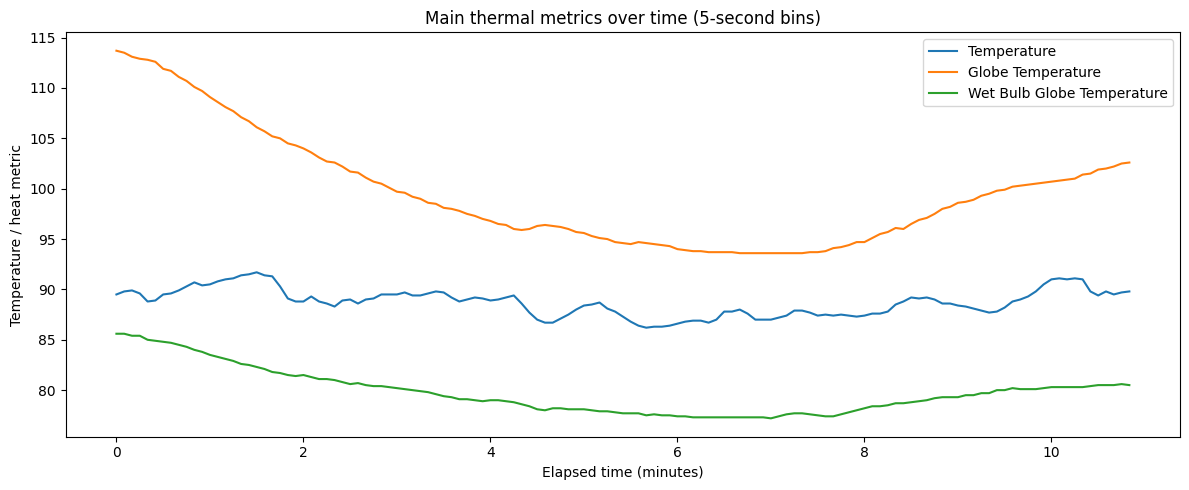

In [29]:
plt.figure(figsize=(12, 5))
for col in ["Temperature", "Globe Temperature", "Wet Bulb Globe Temperature"]:
    if col in work.columns:
        plt.plot(work["elapsed_minutes"], work[col], label=col)

plt.xlabel("Elapsed time (minutes)")
plt.ylabel("Temperature / heat metric")
plt.title("Main thermal metrics over time (5-second bins)")
plt.legend()
plt.tight_layout()
plt.show()

---
# Thermal Work Limit / Time
- shows how Thermal Work Limit changes across the route at the 5-second interval.
- Lower TWL indicates a more restrictive thermal environment.

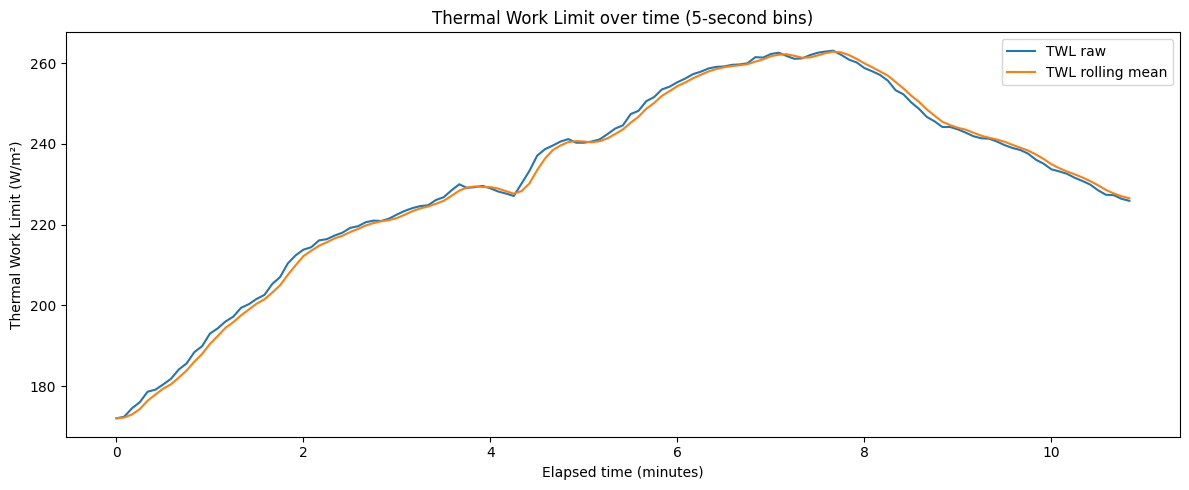

In [30]:
if "Thermal Work Limit" in work.columns:
    plt.figure(figsize=(12, 5))
    plt.plot(work["elapsed_minutes"], work["Thermal Work Limit"], label="TWL raw")
    plt.plot(work["elapsed_minutes"], work["Thermal Work Limit_roll3"], label="TWL rolling mean")
    plt.xlabel("Elapsed time (minutes)")
    plt.ylabel("Thermal Work Limit (W/m²)")
    plt.title("Thermal Work Limit over time (5-second bins)")
    plt.legend()
    plt.tight_layout()
    plt.show()

---
# Histograms of key variables
- These histograms show the distributions of the main heat-related variables
- after alignment to 5-second bins.

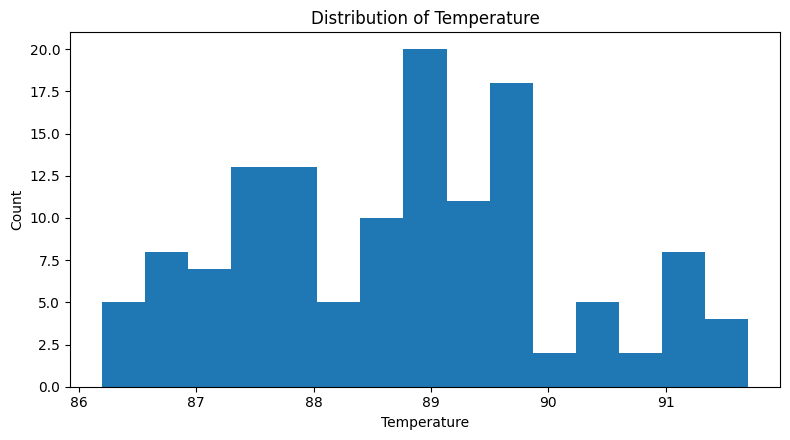

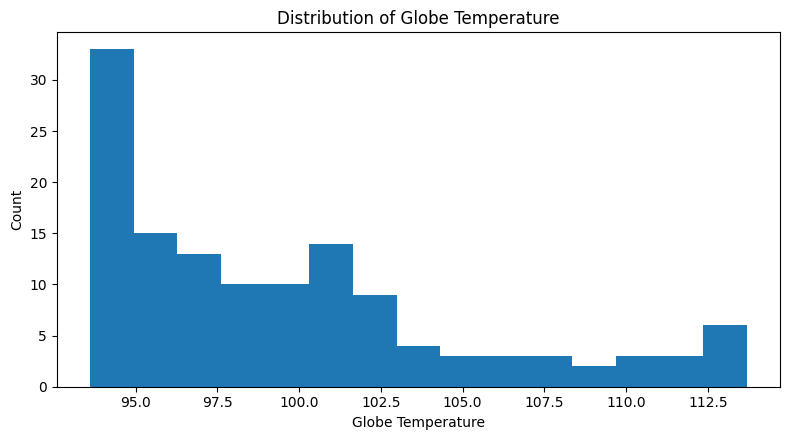

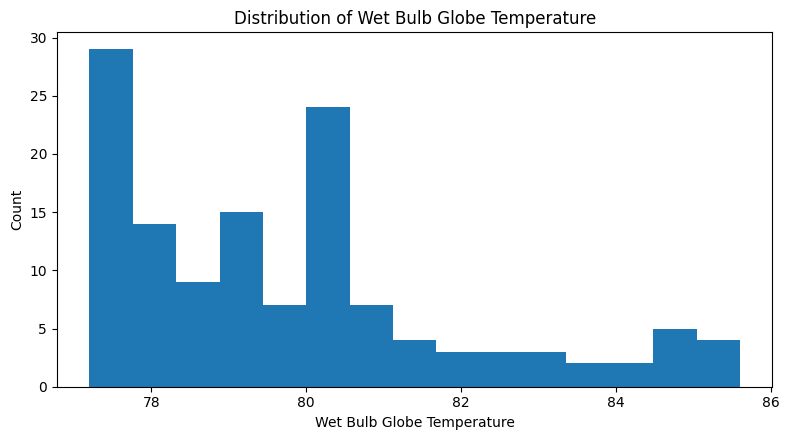

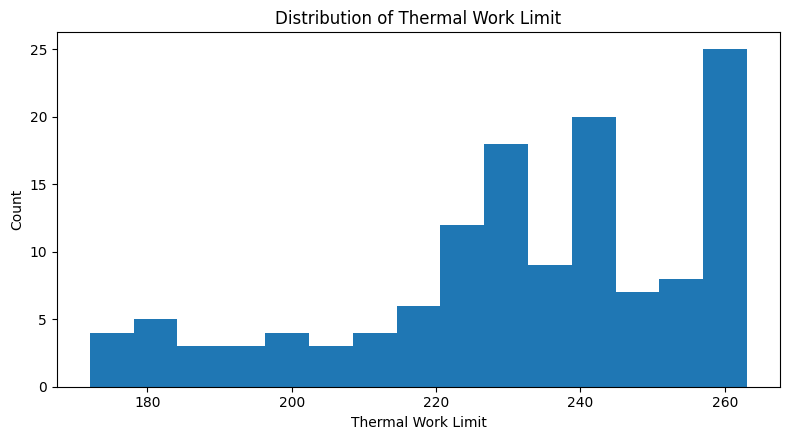

In [31]:
for col in ["Temperature", "Globe Temperature", "Wet Bulb Globe Temperature", "Thermal Work Limit"]:
    if col in work.columns:
        plt.figure(figsize=(8, 4.5))
        plt.hist(work[col].dropna(), bins=15)
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.title(f"Distribution of {col}")
        plt.tight_layout()
        plt.show()

---
# Scatterplots for pattern recognition
- # show exploratory pattern recognition by checking whether stronger heat stress conditions align with lower Thermal Work Limit values.

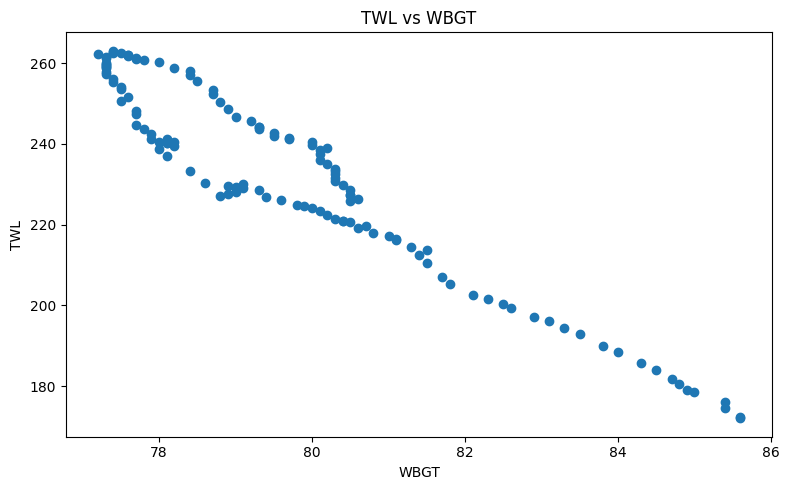

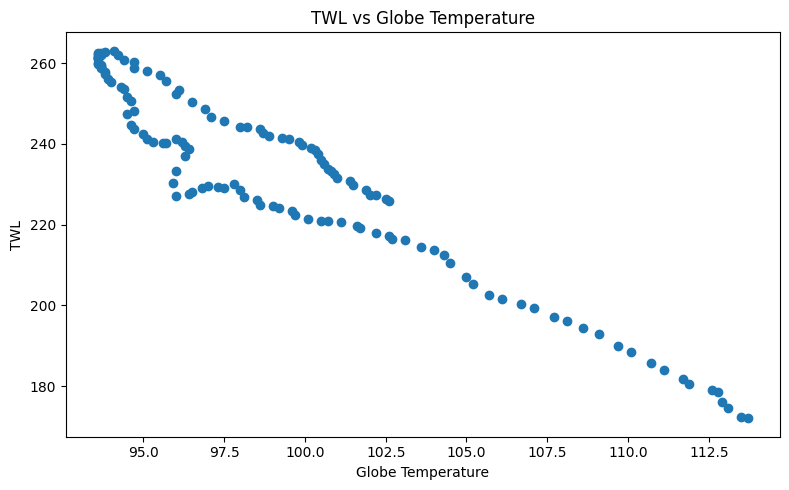

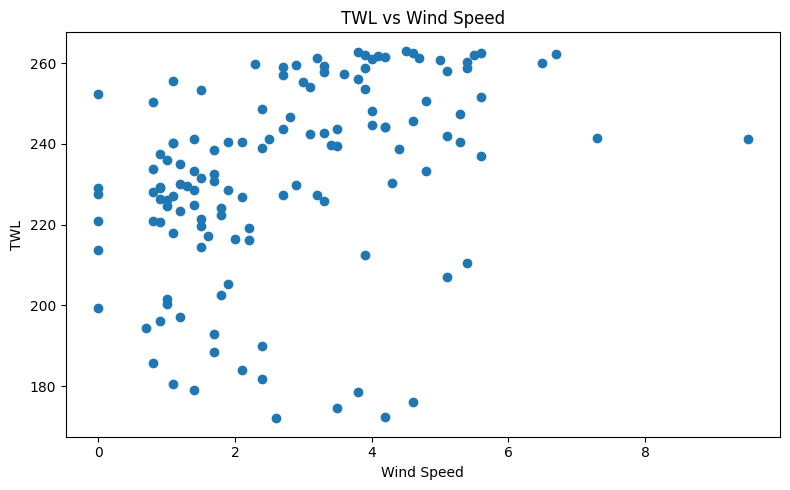

In [32]:
if "Wet Bulb Globe Temperature" in work.columns and "Thermal Work Limit" in work.columns:
    plt.figure(figsize=(8, 5))
    plt.scatter(work["Wet Bulb Globe Temperature"], work["Thermal Work Limit"])
    plt.xlabel("WBGT")
    plt.ylabel("TWL")
    plt.title("TWL vs WBGT")
    plt.tight_layout()
    plt.show()

if "Globe Temperature" in work.columns and "Thermal Work Limit" in work.columns:
    plt.figure(figsize=(8, 5))
    plt.scatter(work["Globe Temperature"], work["Thermal Work Limit"])
    plt.xlabel("Globe Temperature")
    plt.ylabel("TWL")
    plt.title("TWL vs Globe Temperature")
    plt.tight_layout()
    plt.show()

if "Wind Speed" in work.columns and "Thermal Work Limit" in work.columns:
    plt.figure(figsize=(8, 5))
    plt.scatter(work["Wind Speed"], work["Thermal Work Limit"])
    plt.xlabel("Wind Speed")
    plt.ylabel("TWL")
    plt.title("TWL vs Wind Speed")
    plt.tight_layout()
    plt.show()

---
# Identifying Transition Points
- identifies rows where globe temperature changes abruptly between adjacent 5-second bins.
- Large changes may indicate transitions between shaded and unshaded conditions or other route-level microclimate shifts.

In [33]:
if "Globe Temperature_diff" in work.columns:
    transitions = work.loc[
        work["Globe Temperature_diff"].abs() > 2,
        [
            "FORMATTED DATE_TIME",
            "elapsed_minutes",
            "Globe Temperature",
            "Globe Temperature_diff",
            "longitude",
            "latitude"
        ]
    ].copy()

    display(transitions.head(20))

,FORMATTED DATE_TIME,elapsed_minutes,Globe Temperature,Globe Temperature_diff,longitude,latitude


---
# Route preview table
- previews the merged environmental measurements with their matched route coordinates and logger aggregation diagnostics.

In [34]:
route_preview_cols = [c for c in [
    "FORMATTED DATE_TIME",
    "time_bin_5s",
    "longitude",
    "latitude",
    "Temperature",
    "Globe Temperature",
    "Wet Bulb Globe Temperature",
    "Thermal Work Limit",
    "horizontal_accuracy_m",
    "logger_n_points"
] if c in work.columns]

display(work[route_preview_cols].head(20))

,FORMATTED DATE_TIME,time_bin_5s,longitude,latitude,Temperature,Globe Temperature,Wet Bulb Globe Temperature,Thermal Work Limit,horizontal_accuracy_m,logger_n_points
0,2026-03-31 15:52:09,2026-03-31 20:52:05+00:00,-97.737912,30.283295,89.5,113.7,85.6,172.0,14.608559,5
1,2026-03-31 15:52:14,2026-03-31 20:52:10+00:00,-97.737950,30.283282,89.8,113.5,85.6,172.4,14.241556,5
2,2026-03-31 15:52:19,2026-03-31 20:52:15+00:00,-97.737962,30.283319,89.9,113.1,85.4,174.5,13.508042,5
3,2026-03-31 15:52:24,2026-03-31 20:52:20+00:00,-97.737957,30.283339,89.6,112.9,85.4,176.0,13.835223,5
4,2026-03-31 15:52:29,2026-03-31 20:52:25+00:00,-97.737953,30.283374,88.8,112.8,85.0,178.6,15.076521,5
5,2026-03-31 15:52:34,2026-03-31 20:52:30+00:00,-97.737881,30.283414,88.9,112.6,84.9,179.1,14.760135,5
6,2026-03-31 15:52:39,2026-03-31 20:52:35+00:00,-97.737775,30.283375,89.5,111.9,84.8,180.4,14.245955,5
7,2026-03-31 15:52:44,2026-03-31 20:52:40+00:00,-97.737714,30.283369,89.6,111.7,84.7,181.8,14.245955,5
8,2026-03-31 15:52:49,2026-03-31 20:52:45+00:00,-97.737661,30.283356,89.9,111.1,84.5,184.1,14.245955,5
9,2026-03-31 15:52:54,2026-03-31 20:52:50+00:00,-97.737603,30.283374,90.3,110.7,84.3,185.6,14.245955,5


---
# Exporting results to  saved files
- saves the cleaned Kestrel dataset, cleaned logger dataset, 5-second logger aggregation, 5-second Kestrel table, merged full table, working analysis table, and summary outputs.

In [35]:
df.to_csv("../Data_Analysis/kestrel_parsed_clean.csv", index=False)
logger.to_csv("../Data_Analysis/logger_parsed_clean.csv", index=False)
logger_agg.to_csv("../Data_Analysis/logger_aggregated_5s.csv", index=False)
df_5s.to_csv("../Data_Analysis/kestrel_binned_5s.csv", index=False)
merged.to_csv("../Data_Analysis/kestrel_logger_merged_5s_full.csv", index=False)
work.to_csv("../Data_Analysis/kestrel_logger_analysis_working_5s.csv", index=False)
summary.to_csv("../Data_Analysis/kestrel_logger_summary_5s.csv")
corr.to_csv("../Data_Analysis/kestrel_logger_correlations_5s.csv")

print("Saved cleaned and analysis-ready outputs.")

Saved cleaned and analysis-ready outputs.


# README
## Merge methodology

The Kestrel environmental dataset and the logger route dataset were aligned using **5-second bins**, because the Kestrel data were recorded at approximately 5-second intervals.

- The logger timestamps were recorded in ISO 8601 UTC format and parsed directly.
- The Kestrel timestamps were recorded as local clock time and therefore localized to America/Chicago before conversion to UTC.
- Both datasets were assigned to a common `time_bin_5s` field using `floor("5s")`.
- The logger data were aggregated within each 5-second bin.
- The Kestrel data were reduced to one row per 5-second bin.
- The two binned datasets were then merged exactly on `time_bin_5s`.

This approach preserves the native temporal resolution of the environmental measurements and avoids unnecessary over-precision from the faster logger data.

## Analysis workflow

After merging, the data were processed using a standard workflow:

1. timestamp standardization and bin alignment  
2. numeric conversion and basic cleaning  
3. logger-bin aggregation diagnostics  
4. missingness review  
5. descriptive statistics  
6. rolling averages and first differences for pattern recognition  
7. time-series visualization of major heat metrics  
8. scatterplots and correlation analysis  
9. inspection of likely transition points between microclimates

# END
---

In [36]:
# Jupyter Notebook cell
# Purpose:
# 1) Plot your walking route on an interactive map
# 2) Show a small number of clearly spaced environmental markers
# 3) Default selection = 5 markers total:
#    start, 3 evenly spaced middle points, end
#
# Assumes your merged dataframe is named `merged`
# and contains at least:
#   latitude, longitude
# plus whichever environmental columns you want to display.

%pip install folium
import pandas as pd
import folium
from IPython.display import display

Note: you may need to restart the kernel to use updated packages.


In [39]:
# Jupyter Notebook cell
# Purpose:
# 1) Plot your walking route on an interactive map
# 2) Show a small number of clearly spaced environmental markers
# 3) Default selection = 5 markers total:
#    start, 3 evenly spaced middle points, end
#
# Assumes your merged dataframe is named `merged`
# and contains at least:
#   latitude, longitude
# plus whichever environmental columns you want to display.

import pandas as pd
import folium
from IPython.display import display

# -----------------------------
# 1. CONFIGURE YOUR COLUMN NAMES
# -----------------------------
lat_col = "latitude"
lon_col = "longitude"
time_col = "kestrel_time_utc"

# Environmental fields to show in popup
popup_cols = [
    "Temperature",
    "Globe Temperature",
    "Wet Bulb Globe Temperature",
    "Thermal Work Limit",
    "Relative Humidity",
    "Wind Speed",
    "horizontal_accuracy_m",
    "logger_speed_mps",
]

# Friendly labels for popup
label_map = {
    "Temperature": "Air Temp (°F)",
    "Globe Temperature": "Globe Temp (°F)",
    "Wet Bulb Globe Temperature": "WBGT (°F)",
    "Thermal Work Limit": "TWL (W/m²)",
    "Relative Humidity": "RH (%)",
    "Wind Speed": "Wind Speed",
    "horizontal_accuracy_m": "GPS Horizontal Accuracy (m)",
    "logger_speed_mps": "Walking Speed (m/s)",
}

# -----------------------------
# 2. CLEAN WORKING DATA
# -----------------------------
df = merged.copy()

needed = [lat_col, lon_col]
if time_col in df.columns:
    needed.append(time_col)

df = df.dropna(subset=[lat_col, lon_col]).reset_index(drop=True)

if time_col in df.columns:
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.sort_values(time_col).reset_index(drop=True)

if len(df) < 2:
    raise ValueError("Need at least 2 mapped points to draw a route.")

# -----------------------------
# 3. CHOOSE 5 DISPLAY POINTS:
#    start, 3 evenly spaced, end
# -----------------------------
n_total = len(df)
marker_count = 5

if n_total <= marker_count:
    chosen_idx = list(range(n_total))
else:
    chosen_idx = sorted(set([
        round(i * (n_total - 1) / (marker_count - 1))
        for i in range(marker_count)
    ]))

marker_df = df.iloc[chosen_idx].copy()

# -----------------------------
# 4. BUILD MAP
# -----------------------------
center_lat = df[lat_col].mean()
center_lon = df[lon_col].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=16,
    tiles="OpenStreetMap"
)

# Full route polyline
route_coords = df[[lat_col, lon_col]].values.tolist()
folium.PolyLine(
    route_coords,
    color="blue",
    weight=4,
    opacity=0.8,
    tooltip="Full route"
).add_to(m)

# -----------------------------
# 5. ADD START / MIDDLE / END MARKERS
# -----------------------------
def build_popup(row, position_name):
    lines = [f"<b>{position_name}</b>"]

    if time_col in row.index and pd.notna(row[time_col]):
        lines.append(f"<b>Time:</b> {row[time_col]}")

    for col in popup_cols:
        if col in row.index:
            val = row[col]
            if pd.notna(val):
                if isinstance(val, (int, float)):
                    lines.append(f"<b>{label_map.get(col, col)}:</b> {val:.2f}")
                else:
                    lines.append(f"<b>{label_map.get(col, col)}:</b> {val}")

    return "<br>".join(lines)

for j, (idx, row) in enumerate(marker_df.iterrows()):
    if j == 0:
        name = "Start"
        color = "green"
    elif j == len(marker_df) - 1:
        name = "End"
        color = "red"
    else:
        name = f"Middle {j}"
        color = "orange"

    folium.Marker(
        location=[row[lat_col], row[lon_col]],
        popup=folium.Popup(build_popup(row, name), max_width=350),
        tooltip=name,
        icon=folium.Icon(color=color, icon="info-sign")
    ).add_to(m)

# -----------------------------
# 6. FIT MAP TO ROUTE BOUNDS
# -----------------------------
m.fit_bounds([
    [df[lat_col].min(), df[lon_col].min()],
    [df[lat_col].max(), df[lon_col].max()]
])

m

In [38]:
for c in merged.columns:
    print(c)

FORMATTED DATE_TIME
Temperature
Wet Bulb Temp
Globe Temperature
Relative Humidity
Barometric Pressure
Altitude
Station Pressure
Wind Speed
Heat Index
Dew Point
Density Altitude
Crosswind
Headwind
Compass Magnetic Direction
NWB Temp
Compass True Direction
Thermal Work Limit
Wet Bulb Globe Temperature
Wind Chill
Humidex Canada
Data Type
Record name
Start time
Duration (H:M:S)
Location description
Location address
Location coordinates
Notes
kestrel_time_utc
elapsed_seconds
elapsed_minutes
time_bin_5s
logger_n_points
logger_time_first_utc
logger_time_last_utc
longitude
latitude
altitude
horizontal_accuracy_m
vertical_accuracy_m
logger_speed_mps
logger_speed_accuracy_mps
logger_course_deg
logger_course_accuracy_deg
matched_logger
time_diff_to_logger_first_seconds
time_diff_to_logger_last_seconds
dt_seconds


In [40]:
import webbrowser
from pathlib import Path

map_path = Path("kestrel_route_map.html").resolve()
m.save(map_path)
webbrowser.open(f"file://{map_path}")
print(map_path)

/Users/robertzygmuntlehr/Desktop/Research/notebooks/kestrel_route_map.html
